**The King of Limbs - Squad Classifier**

Loading Data

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

drive.mount('/content/drive')
file_path = "/content/drive/My Drive/Colab Notebooks/Imperial/AML Lab/Data Sets/2025_02_27_DB_TKoL_v1.csv"
df = pd.read_csv(file_path)
#df.head()

Mounted at /content/drive


Preprocessing

In [ ]:
# print(df[['Timestamp']].head(20))  # Show original values before conversion
# print(df['Timestamp'].dtype)  # Check current data type

df['Timestamp'] = df['Timestamp'].astype(str)  # Ensure it's a string

df['Timestamp'] = '2024-02-26 ' + df['Timestamp']

# Convert Timestamp to Numeric
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df['Timestamp'] = df['Timestamp'].astype('int64') // 10**9  # Convert to seconds

imu_counts = df.groupby('Timestamp').size()
valid_timestamps = imu_counts[imu_counts >= 5].index  # Keep timestamps with at least 5 IMUs
df = df[df['Timestamp'].isin(valid_timestamps)]  # Filter dataset

# Group by timestamp
grouped_data = df.groupby('Timestamp')
X = []  # Features (Sensor data for each timestamp)
y = []  # Target labels (Squat type)

sensor_columns = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Heading']

for _, group in grouped_data:
    if len(group) >= 5: 
        imu_data = group[sensor_columns].values[:5] 
        X.append(imu_data)
        y.append(group['Squat'].iloc[0])

X = np.array(X)
y = np.array(y)

print(f"Processed Data Shape: {X.shape}")  # DEBUG: (num_samples, 5, num_features)
print(f"Labels Shape: {y.shape}")  # DEBUG: (num_samples,)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Convert labels to numbers
y = to_categorical(y)  # Convert to one-hot encoding

print(f"One-Hot Encoded Labels Shape: {y.shape}")  # DUBUG: (num_samples, num_classes)

Processed Data Shape: (2381, 5, 10)
Labels Shape: (2381,)
One-Hot Encoded Labels Shape: (2381, 3)


In [ ]:
# Split dataset (80% Train, 10% Validation, 10% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=True, random_state=42)

# DEBUG: Print shapes
print(f"Training Set: {X_train.shape}, {y_train.shape}")
print(f"Validation Set: {X_val.shape}, {y_val.shape}")
print(f"Testing Set: {X_test.shape}, {y_test.shape}")

Training Set: (1904, 5, 10), (1904, 3)
Validation Set: (238, 5, 10), (238, 3)
Testing Set: (239, 5, 10), (239, 3)


In [ ]:
# LSTM Model
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(50, activation="relu"),
    Dense(y.shape[1], activation="softmax")  # Multi-class classification
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4926 - loss: 1.0071 - val_accuracy: 0.8109 - val_loss: 0.5675
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7995 - loss: 0.4944 - val_accuracy: 0.8950 - val_loss: 0.3104
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8917 - loss: 0.2944 - val_accuracy: 0.8992 - val_loss: 0.2573
Epoch 4/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9250 - loss: 0.2080 - val_accuracy: 0.8992 - val_loss: 0.2482
Epoch 5/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9256 - loss: 0.1930 - val_accuracy: 0.9160 - val_loss: 0.2154
Epoch 6/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9371 - loss: 0.1580 - val_accuracy: 0.8908 - val_loss: 0.2736
Epoch 7/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9440 - loss: 0.1516 - val_accuracy: 0.9160 - val_loss: 0.2095
Epoch 8/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9494 - loss: 0.1323 - val_accuracy: 0.9202 - val_loss: 0.

In [ ]:
model.save("/content/drive/My Drive/squat_model.h5")  # Saves to Google Drive

In [ ]:
model.save("/content/drive/My Drive/squat_model.keras")  # Recommended Keras format

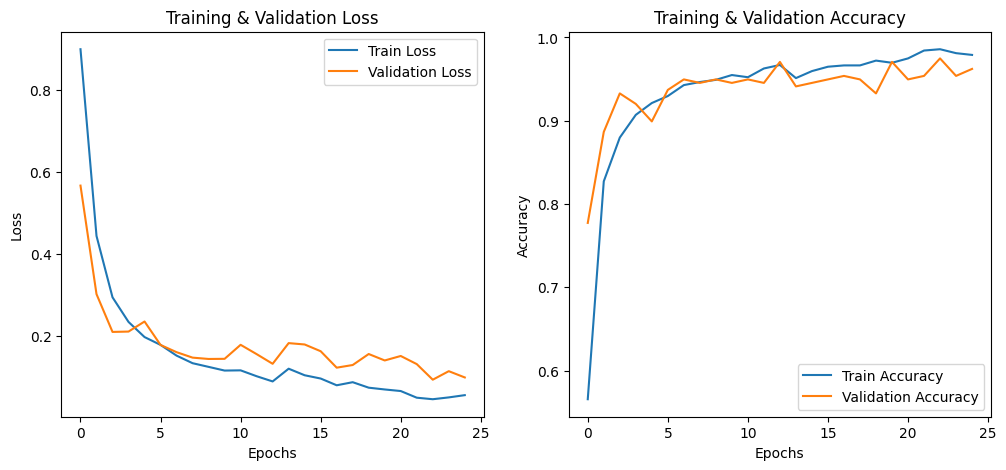

In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()


In [ ]:
# Evaluate on Test Set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9771 - loss: 0.0761 
Test Accuracy: 96.65%


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


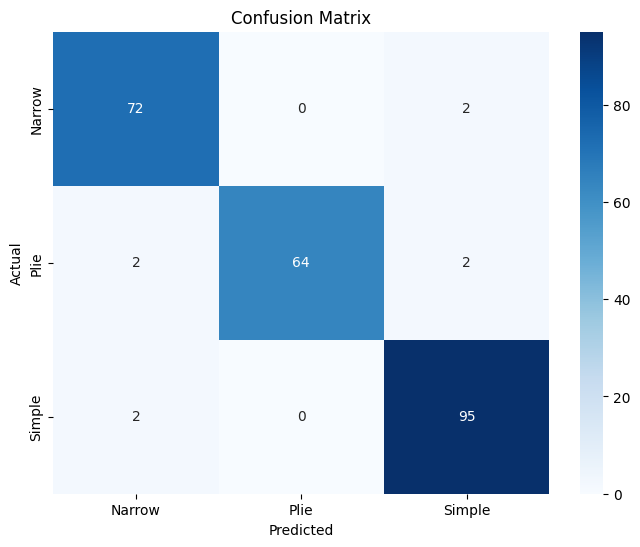

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Compute Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

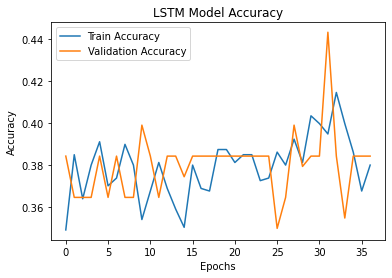

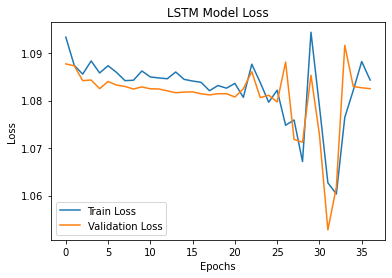

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Model Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('LSTM Model Loss')
plt.show()
